# Model Evaluation

In this notebook, we built various models to predict vehicle prices and evaluated their accuracy using different techniques. This section provides an overview of the models, performance metrics, and methods used to ensure reliable and generalizable predictions.

## Dataset
The dataset for this project is hosted on [IBM Cloud](https://cocl.us/DA101EN_object_storage). It contains various features related to vehicle specifications, which were used to build and evaluate our regression models.

## Table of Contents 

1. [Import Data and Setup](#import-data)<br>
2. [Training and Testing](#train-test)<br>
    2.1 [Cross-Validation](#cross)<br>
3. [Overfitting, Underfitting and Model Selection](#over-under)<br>
    3.1 [Overfitting](#over)<br>
4. [Ridge Regression](#ridge-rg)<br>
5. [Grid Search](#grid)<br>
    5.1. [Define Grid Search Parameters](#define-grid)<br>
    5.2. [Evaluate Best Model](#best-model)<br>
    5.3. [Final Model Training and Evaluation](#final-model)<br>
6. [Conclusions](#conclusions)<br>

---

## 1. Import Data and Setup <a id="import-data"></a>

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load Data
path = 'https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DA0101EN/module_5_auto.csv'
df = pd.read_csv(path)

# Get only numerical columns
df = df._get_numeric_data()

# Fill missing values with the mean of each column
df.fillna(df.mean(), inplace=True)

df.head()

,Unnamed: 0.1,Unnamed: 0,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
0,0,0,3,122,88.6,0.811148,0.890278,48.8,2548,130,...,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,0,1
1,1,1,3,122,88.6,0.811148,0.890278,48.8,2548,130,...,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,0,1
2,2,2,1,122,94.5,0.822681,0.909722,52.4,2823,152,...,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,0,1
3,3,3,2,164,99.8,0.848630,0.919444,54.3,2337,109,...,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,0,1
4,4,4,2,164,99.4,0.848630,0.922222,54.3,2824,136,...,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,0,1


## 2. Training and Testing <a id="train-test"></a>
In machine learning, the dataset is typically split into two parts:

- **Training set**: Used to train the model, allowing it to learn patterns and relationships from the data.
- **Testing set**: Used to evaluate the model's performance on unseen data, ensuring it generalizes well.

The goal is to train the model on one portion of the data and assess its accuracy on a separate, unseen portion.

In [3]:
# Input variables
X = df.drop(columns=['price'])
y = df['price']


In [4]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Test Samples :", X_test.shape[0])
print("Training Samples:", X_train.shape[0])

Test Samples : 41
Training Samples: 160


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train a model (e.g., Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = model.predict(X_test)

# Evaluate the model using MAE, MSE, and R²
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Evaluation Metrics
print(f"MAE: {mae:.4}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE: 3.286e+03
MSE: 23278250.3545
R2 Score: 0.8097


### 2.1. Cross-Validation <a id="cross"></a>
Sometimes you do not have sufficient testing data; as a result, you may want to perform **cross-validation**. Cross-validation allows you to make the most of your data by splitting it into multiple parts to train and test the model.

#### Types of Cross-Validation:
1. **K-Fold Cross-Validation**:
   - The dataset is divided into \(k\) subsets (or "folds").
   - The model is trained on \(k-1\) folds and tested on the remaining fold. This process repeats for each fold, and the results are averaged to evaluate model performance.

2. **Leave-One-Out Cross-Validation (LOO-CV)**:
   - A special case of k-fold where \(k\) is equal to the number of data points.
   - Each individual data point is used as a test set while the rest are used for training. This is repeated for each data point.

3. **Stratified K-Fold Cross-Validation**:
   - Similar to k-fold but ensures that each fold has the same proportion of target class labels as the original dataset.
   - Particularly useful for imbalanced datasets.

Cross-validation helps to mitigate issues like overfitting and provides a more reliable estimate of model performance, especially when limited testing data is available.

**Example: K-Fold Cross-Validation with Scikit-Learn**

Here’s an example of how to use **K-Fold Cross-Validation** in Python using `scikit-learn`:

In [6]:
from sklearn.model_selection import cross_val_score

In [7]:
# Input variables
X = df.drop(columns=['price'])
y = df['price']

# Initialize the model
model = LinearRegression()

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5)

# Print the mean and standard deviation of the cross-validation scores
print(f'Cross-validation scores: {cv_scores}')
print(f'Mean score: {cv_scores.mean():.4}')
print(f'Standard deviation: {cv_scores.std():.4}')

Cross-validation scores: [ 0.77176305  0.87751254 -0.02091486  0.70668968  0.51742913]
Mean score: 0.5705
Standard deviation: 0.3181


**Cross-validation** is performed using cross_val_score for $R^2$ and `cross_val_predict` to get predictions for calculating **MAE** and **MSE**:

In [8]:
from sklearn.model_selection import cross_val_predict

# Perform cross-validation to get predictions
y_pred = cross_val_predict(model, X, y, cv=5)
print(y_pred[:5])

# Calculate MAE and MSE
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)

# Evaluation Metrics
print(f"MAE: {mae:.4}")
print(f"MSE: {mse:.4f}")

[12875.24919615 12868.94603408 16800.92304512 11302.98436825
 16858.79496265]
MAE: 2.749e+03
MSE: 15350250.8786


## 3. Overfitting, Underfitting and Model Selection <a id="over-under"></a>

It turns out that the **test data**, sometimes referred to as the **out-of-sample data**, is a much better measure of how well your model performs in the real world. One reason for this is **overfitting**.

Overfitting occurs when the model learns the details and noise in the training data to such an extent that it negatively impacts the performance of the model on new data.

Let's go over some examples of **overfitting** and **underfitting**. These differences are more apparent in **Multiple Linear Regression** and **Polynomial Regression**, so we will explore **overfitting** in that context.

- **Overfitting**: The model fits the training data too well, capturing noise and leading to poor generalization on unseen data.
- **Underfitting**: The model is too simple to capture the underlying patterns in the data, resulting in poor performance on both training and test data.

In both cases, model selection plays a crucial role. The goal is to find a model that is **complex enough** to capture important patterns in the data, but **simple enough** to generalize well to new data.

In [9]:
# Input variables
X = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df['price']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Linear Regression model on Training Data
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


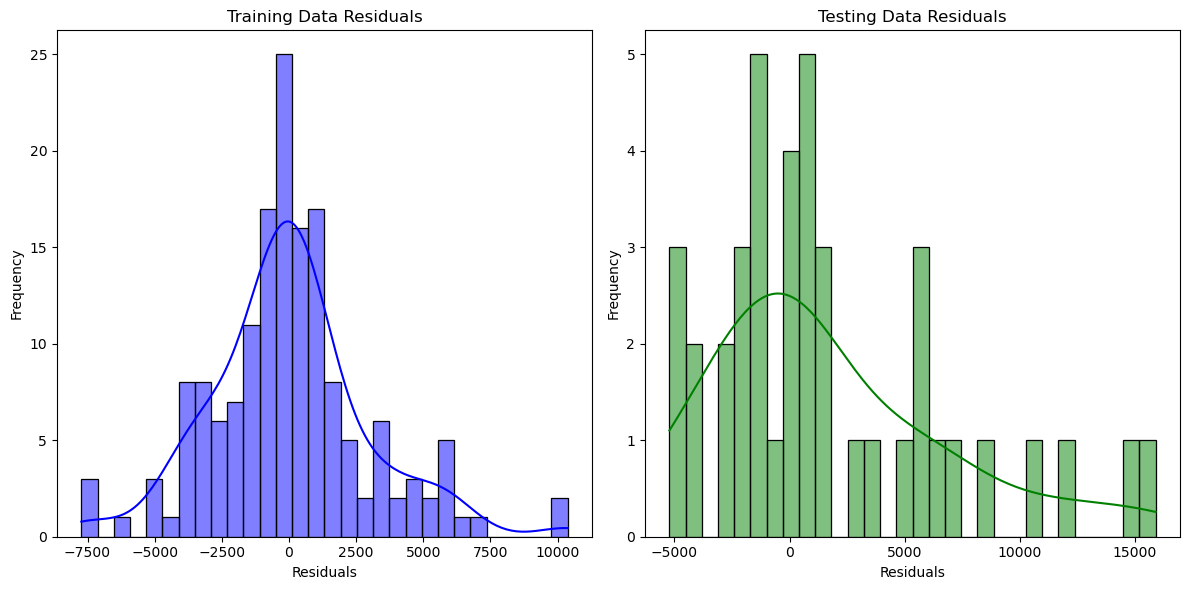

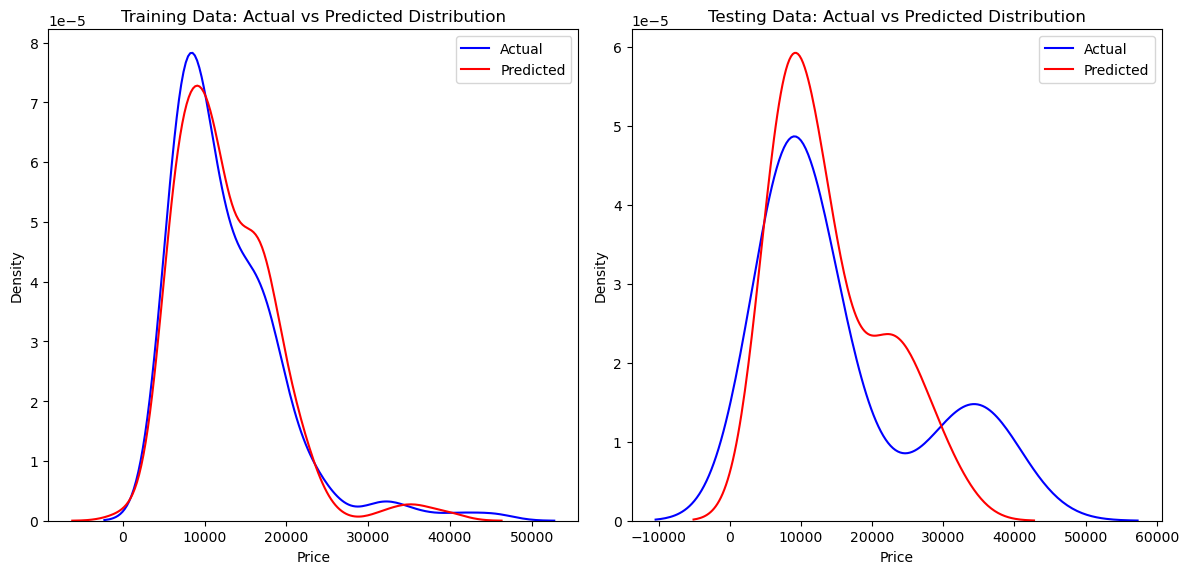

In [10]:
import seaborn as sns

# Calculate residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Plot residuals for training and testing
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(residuals_train, kde=True, color='blue', bins=30)
plt.title('Training Data Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(residuals_test, kde=True, color='green', bins=30)
plt.title('Testing Data Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Plot the distribution of actual vs predicted values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(y_train, color='blue', label='Actual')
sns.kdeplot(y_pred_train, color='red', label='Predicted')
plt.title('Training Data: Actual vs Predicted Distribution')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(y_test, color='blue', label='Actual')
sns.kdeplot(y_pred_test, color='red', label='Predicted')
plt.title('Testing Data: Actual vs Predicted Distribution')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()

**Analysis of the Residuals and Distribution Plots**
- **Training and Testing Residuals**:
    - **Training**:
        The distribution of residuals for the training data shows a relatively smooth bell-shaped curve, which is typically a good sign. However, the presence of some spread suggests that the model is capturing most but not all of the patterns. Some noise is still present.
    - **Test**: 
        The testing data residual plot shows a similar spread. However, the wider distribution compared to the training residuals suggests that the model is not generalizing as well to unseen data. This could be a sign of **overfitting**, *where the model performs well on the training data but struggles to predict accurately on the testing data*.

- **Actual vs Predicted Distribution**:
    - **Training**:
        The training data distribution of actual vs predicted values shows that the predictions are somewhat tightly clustered around the actual values, indicating that the model has captured the underlying patterns in the training data fairly well. However, there is still some deviation, suggesting potential room for improvement. 

    - **Test**:
        The testing data plot, where the predicted values diverge more significantly from the actual values, highlights that the model does not generalize well to unseen data. This further suggests **overfitting**. The predicted values are skewed and do not match the actual values as closely as in the training data, indicating a lack of generalization.

### 3.1. Overfitting <a id="over"></a>

**Overfitting** occurs when the model fits the training data **too well**, capturing not only the underlying patterns but also the **noise** in the data. As a result, the model performs poorly on unseen data because it has learned patterns specific to the training set that do not generalize to new data.

When testing your model using the **test-set**, your model does not perform as well because it is modeling noise rather than the true relationship between the features and the target variable.

In [11]:
from sklearn.preprocessing import PolynomialFeatures

Degree 1: R2 Score = 0.6233
Degree 2: R2 Score = 0.6270
Degree 3: R2 Score = 0.6304
Degree 4: R2 Score = 0.6398
Degree 5: R2 Score = 0.6404
Degree 6: R2 Score = 0.6450
Degree 7: R2 Score = 0.6510
Degree 8: R2 Score = 0.6536
Degree 9: R2 Score = 0.6526
Degree 10: R2 Score = 0.6470
Degree 11: R2 Score = 0.6451
Degree 12: R2 Score = 0.6401
Degree 13: R2 Score = 0.6307
Degree 14: R2 Score = 0.6174


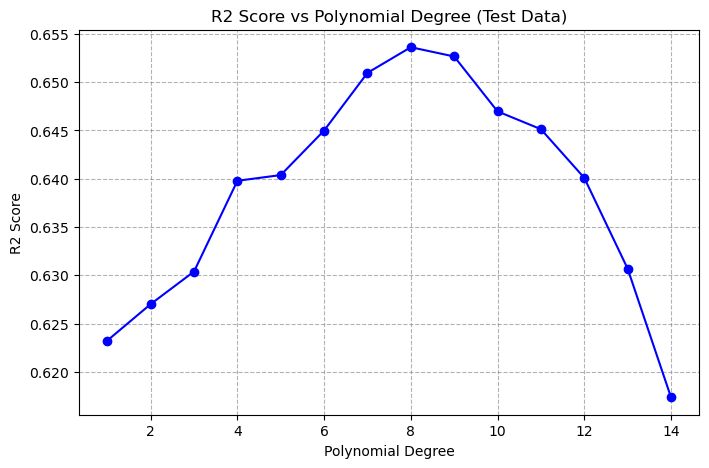

In [12]:
# Input variables
X = df[['horsepower']]
y = df['price']
degrees = range(1, 15)  # Degrees of polynomial to test

# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize list to store R² scores
r2_scores = []

# Iterate over different polynomial degrees
for degree in degrees:
    # Generate polynomial features for the current degree
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train a Linear Regression model on the polynomial features
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predict on the test data
    y_pred_test = model.predict(X_test_poly)
    
    # Evaluate the model using R2 score
    r2 = r2_score(y_test, y_pred_test)
    print(f"Degree {degree}: R2 Score = {r2:.4f}")
    r2_scores.append(r2)

# Plot R2 scores against polynomial degree
plt.figure(figsize=(8, 5))
plt.plot(degrees, r2_scores, marker='o', linestyle='-', color='blue')
plt.xlabel('Polynomial Degree')
plt.ylabel('R2 Score')
plt.title('R2 Score vs Polynomial Degree (Test Data)')
plt.grid(True, linestyle='--', color='grey', alpha=0.6)
plt.show()


#### Analysis of R² Score vs. Polynomial Degree
- **Overall Trend**:
    - The **R² Score** initially improves as the polynomial degree increases, reaching a peak around **degree 8**.
    - After degree 8, the R² score starts declining, suggesting that adding more complexity does not improve the model's generalization.

- **Optimal Degree**:
    - **Degree 8** gives the highest **R² score** on the test data, indicating that this degree likely captures the data's underlying patterns without overfitting or underfitting.

- **Overfitting**:
    - After degree 8, the drop in **R²** suggests **overfitting**. The model becomes too complex, capturing noise in the training data rather than meaningful trends, which results in poor performance on the test set.

- **Underfitting**:
    - For degrees 1 to 3, the **R² score** is relatively low, indicating **underfitting**, where the model is too simple to capture the relationships in the data.

Based on the plot, **degree 8** provides the best balance of fit and generalization. It's advisable to use this degree for **final model evaluation** and **predictions**.


In [13]:
from ipywidgets import interact, widgets
%matplotlib inline
# Define the interactive polynomial fitting function
def interactive_polynomial(X, y, degree, pct_test):
    """
    Interactive function to visualize polynomial regression fit and performance.

    Parameters:
    - X (pd.DataFrame): The independent variable(s).
    - y (pd.Series): The target variable.
    - degree (int): Degree of the polynomial features.
    - pct_test (float): Percentage of data to be used for testing.

    Returns:
    - None
    """

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=pct_test, random_state=42)

    # Create polynomial features for the specified degree
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train the model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predict and evaluate the model
    y_pred_test = model.predict(X_test_poly)
    r2 = r2_score(y_test, y_pred_test)
    print(f"Degree {degree} -> R² Score: {r2:.4f}")

    # Generate data for plotting the polynomial curve
    x_new = pd.DataFrame(np.linspace(X.min().values[0], X.max().values[0], 100), columns=['horsepower'])
    x_new_poly = poly.transform(x_new)
    y_pred_plot = model.predict(x_new_poly)

    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train, y_train, color='#AEC6CF', label='Training Data')
    plt.scatter(X_test, y_test, color='orange', label='Test Data')
    plt.plot(x_new, y_pred_plot, color='red', label=f'Polynomial Fit (degree={degree})')
    plt.xlabel('Horsepower')
    plt.ylabel('Price')
    plt.title(f'Polynomial Regression Fit (Degree {degree})')
    plt.legend()
    plt.grid(True, linestyle='--', color='grey', alpha=0.6)
    plt.show()

# Input variables
X = df[['horsepower']]
y = df['price']

# Interactive visualization with sliders for degree and test size percentage
interact(
    interactive_polynomial,
    X=widgets.fixed(X),
    y=widgets.fixed(y),
    degree=widgets.IntSlider(min=1, max=15, step=1, value=8, description='Degree'),
    pct_test=widgets.FloatSlider(min=0.1, max=0.9, step=0.1, value=0.2, description='Test Size')
)

interactive(children=(IntSlider(value=8, description='Degree', max=15, min=1), FloatSlider(value=0.2, descript…

<function __main__.interactive_polynomial(X, y, degree, pct_test)>

## 4. Ridge regression <a id="ridge_reg"></a>

As we progress to more complex machine learning algorithms, **Ridge Regression** is a regularized linear model designed to improve performance by reducing overfitting. Ridge Regression applies **L2 regularization**, which adds a penalty proportional to the square of the coefficients' magnitudes. This reduces the complexity of the model by discouraging excessively large coefficient values.

### Ridge Regression Objective Function**
The loss function is adjusted to include the regularization term:

$$
\text{Loss} = \text{RSS} + \alpha \sum_{i=1}^{n} \beta_i^2
$$

- **RSS**: Residual Sum of Squares.
- **α (alpha)**: Regularization strength (hyperparameter).
- **β**: Coefficients of the features.

When **α = 0**, Ridge Regression behaves like regular linear regression. As **α** increases, the model shrinks coefficients toward zero, controlling overfitting.

### Example: Ridge Regression in Action

In [14]:
from sklearn.linear_model import Ridge

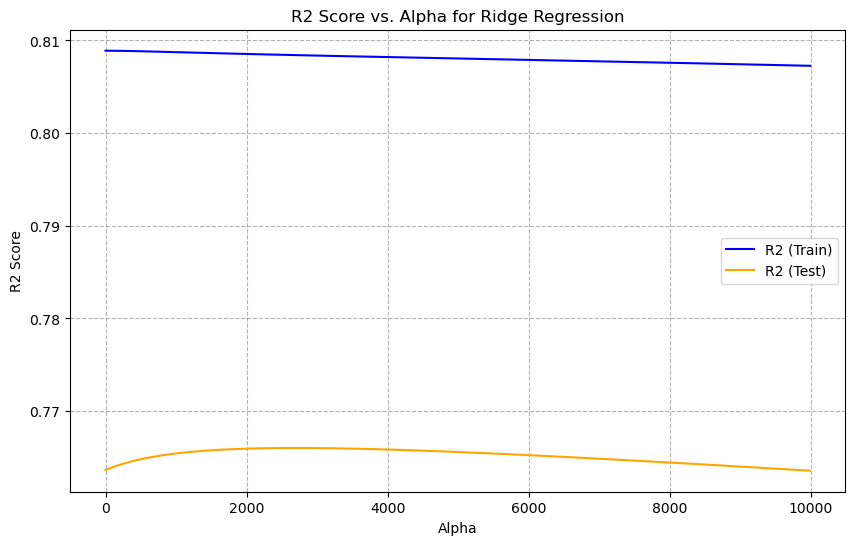

In [15]:
# Input variables
X = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df['price']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

r2_train_scores = []
r2_test_scores = []

alpha_values = 10 * np.array(range(0, 1000))
for alpha_val in alpha_values:
    # Initialize and train the Ridge regression model
    ridge_model = Ridge(alpha=alpha_val)
    ridge_model.fit(X_train, y_train)

    # Predict on both training and testing data
    y_pred_train = ridge_model.predict(X_train)
    y_pred_test = ridge_model.predict(X_test)

    # Calculate R2 scores
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    # Append scores to lists
    r2_train_scores.append(r2_train)
    r2_test_scores.append(r2_test)
    
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, r2_train_scores, label='R2 (Train)', color='blue')
plt.plot(alpha_values, r2_test_scores, label='R2 (Test)', color='orange')
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.title('R2 Score vs. Alpha for Ridge Regression')
plt.legend()
plt.grid(True, linestyle='--', color='grey', alpha=0.6)
plt.show()

The optimal alpha value likely lies between 1 and 1000, where the test score is relatively high and stable.

Higher alpha values can prevent overfitting but may also degrade performance on the test data if the model underfits.

## 5. Grid Search <a id="grid"></a>
In this section, we use Grid Search with cross-validation to find the optimal hyperparameters for the Ridge Regression model. This approach automates the search process over a defined parameter grid to find the best model configuration.

In [16]:
from sklearn.model_selection import GridSearchCV

### 5.1. Define Grid Search Parameters <a id="define-grid"></a>
We specify the values for alpha to test and use GridSearchCV for cross-validation.

In [17]:
# Input variables
X = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df['price']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid
param_grid = {'alpha': [0.001,0.1,1, 10, 100, 1000, 10000, 100000, 100000]}

# Initialize the Ridge model
ridge = Ridge()

# Initialize Grid Search with cross-validation (cv=5 folds)
grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5, scoring='r2')

# Fit the Grid Search on training data
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000,
                                   100000]},
             scoring='r2')

### 5.2. Evaluate Best Model <a id="best-model"></a>
After fitting the grid search, we can extract and analyze the best hyperparameters and their performance:


In [18]:
# Get the best model and hyperparameters
best_model = grid_search.best_estimator_
best_alpha = grid_search.best_params_['alpha']
best_score = grid_search.best_score_

print(f"Best Alpha: {best_alpha}")
print(f"Cross-validated R2 Score: {best_score:.4f}")


Best Alpha: 10000
Cross-validated R2 Score: 0.7609


### 5.3. Final Model Training and Evaluation <a id="final-model"></a>
Now, we retrain the model with the optimal alpha and evaluate its performance:

In [19]:
# Train the best model on the entire training set
best_model.fit(X_train, y_train)

# Make predictions
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Evaluation Metrics
print(f"Training R2 Score: {r2_score(y_train, y_pred_train):.4f}")
print(f"Testing R2 Score: {r2_score(y_test, y_pred_test):.4f}")
print(f"MAE on Test Data: {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"MSE on Test Data: {mean_squared_error(y_test, y_pred_test):.2f}")


Training R2 Score: 0.8073
Testing R2 Score: 0.7636
MAE on Test Data: 3706.82
MSE on Test Data: 28926146.43


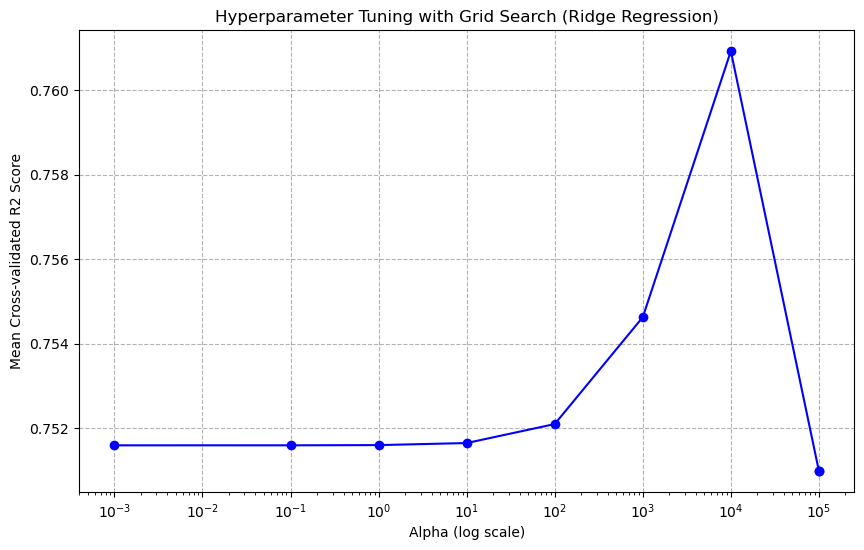

In [20]:
# Extract R2 scores from grid search results
alpha_values = param_grid['alpha']
cv_results = grid_search.cv_results_
mean_test_scores = cv_results['mean_test_score']

# Plot R² scores vs. alpha values
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, mean_test_scores, marker='o', linestyle='-', color='blue')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean Cross-validated R2 Score')
plt.title('Hyperparameter Tuning with Grid Search (Ridge Regression)')
plt.grid(True, linestyle='--', color='grey', alpha=0.6)
plt.show()


The grid search suggests that moderate regularization (`alpha = 10,000`) balances the bias-variance tradeoff well.

Fine-tuning hyperparameters like alpha can significantly enhance the model's predictive performance, as seen in this plot.

## 6. Conclusions <a id="conclusions"></a>

Through this notebook, we explored multiple machine learning models and evaluated them on their ability to predict vehicle prices. Here are the key takeaways:

### Model Performance Summary
1. **Model Evaluation**:
   - We used metrics such as **R² score**, **Mean Absolute Error (MAE)**, and **Mean Squared Error (MSE)** to evaluate the models.
   - The balance between training and testing performance helped us understand how well the models generalized to unseen data.

2. **Cross-Validation**:
   - Cross-validation provided a robust estimate of model performance by using different training and testing splits.
   - It helped reduce the likelihood of overfitting or underfitting by providing a more reliable performance metric.

3. **Overfitting and Underfitting**:
   - Overfitting occurs when a model captures noise instead of patterns, resulting in high training performance but poor test results.
   - Underfitting occurs when a model is too simple, failing to capture the underlying structure of the data.
   - We observed and mitigated these issues by tuning hyperparameters, such as **alpha** in Ridge Regression.

4. **Ridge Regression**:
   - Ridge Regression addressed overfitting by adding a penalty term to the model's complexity.
   - By plotting the **R² score** across various alpha values, we identified an optimal level of regularization that improved generalization.

5. **Grid Search for Hyperparameter Tuning**:
   - Grid Search allowed us to systematically search for the best hyperparameters by testing a wide range of alpha values.
   - The cross-validated results demonstrated that moderate regularization (alpha ≈ 10,000) provided the best performance.
   - This process highlighted the importance of fine-tuning model parameters for optimal predictive performance.


### Final Thoughts
- The combination of feature selection, cross-validation, regularization techniques, and hyperparameter tuning significantly enhanced the accuracy of our vehicle price predictions.
- By following a systematic approach to model evaluation, we identified models that balance both training and testing performance, improving generalization to new data.
  

